## SafeDerm — 04. Feature Engineering

Defines the image preprocessing and augmentation pipeline used for training, validation, and testing.

The actual transform logic lives in `src/transforms.py`, not here — this notebook imports it and sanity-checks it visually. Same reasoning as `src/config.py`: one source of truth, so training code and the eventual FastAPI serving code use identical preprocessing.

Nothing here touches labels or split assignment — pure image-side pipeline.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image

from src.config import IMAGES_DIR, TRAIN_SPLIT_PATH
from src.transforms import get_train_transforms, get_eval_transforms, IMAGENET_MEAN, IMAGENET_STD

train_transforms = get_train_transforms()
eval_transforms = get_eval_transforms()

train_df = pd.read_csv(TRAIN_SPLIT_PATH)

### Why ImageNet normalization, not custom stats

The backbone (ResNet, per ADR-002) is pretrained on ImageNet. Its early layers expect input normalized to ImageNet's per-channel mean/std. Computing custom mean/std from HAM10000 and normalizing to that instead would mismatch what the pretrained weights expect — actively working against transfer learning rather than helping it. Keeping ImageNet stats is the standard, correct choice here.

### Sanity check — visualize augmentation

Same image, five augmented versions. Confirms the pipeline produces realistic variation, not corrupted or unrecognizable output.

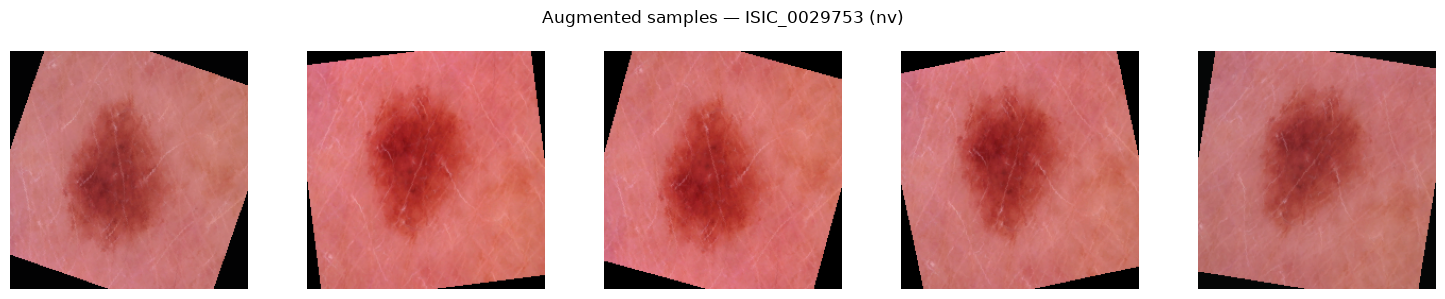

In [2]:
sample_id = train_df["image_id"].sample(1, random_state=42).iloc[0]
sample_dx = train_df[train_df["image_id"] == sample_id]["dx"].iloc[0]
img = Image.open(IMAGES_DIR / f"{sample_id}.jpg")

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax in axes:
    augmented = train_transforms(img)
    # Unnormalize just for display — the model sees normalized tensors, we want to see the image.
    display_img = augmented.permute(1, 2, 0).numpy()
    display_img = display_img * IMAGENET_STD + IMAGENET_MEAN
    display_img = display_img.clip(0, 1)
    ax.imshow(display_img)
    ax.axis("off")

fig.suptitle(f"Augmented samples — {sample_id} ({sample_dx})")
plt.tight_layout()
plt.show()

### Confirm eval transforms have no randomness

Run the same image through `eval_transforms` twice — pixel values must match exactly. If they don't, augmentation has leaked into the evaluation pipeline, which would quietly corrupt val/test metrics.

In [3]:
out1 = eval_transforms(img)
out2 = eval_transforms(img)

assert torch.equal(out1, out2), "eval_transforms is not deterministic — augmentation leaked in!"
print("eval_transforms confirmed deterministic — safe for val/test.")

eval_transforms confirmed deterministic — safe for val/test.


### Summary

- Train pipeline: resize → flip/rotate/color-jitter → normalize (ImageNet stats, matches pretrained backbone)
- Eval pipeline: resize → normalize only, confirmed deterministic above
- Both defined once in `src/transforms.py` — `06_baseline_model.ipynb` and later the FastAPI backend import from here, never redefine
- No modeling decisions made yet. Next: `05_pipeline.ipynb` wires these transforms into an actual PyTorch `Dataset`/`DataLoader`.